# Adversarial Search: Playing Connect 4

Student Name: Thomas Jones

I have used the following AI tools: Claude, Gemini

I understand that my submission needs to be my own work: TJ

## Learning Outcomes

* Implement adversarial search algorithms for strategic game play.
* Analyze and optimize search in complex game spaces.
* Design effective heuristic evaluation functions.
* Compare performance across different agent strategies.
* Evaluate algorithmic trade-offs between decision quality and efficiency.

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state
* Actions
* Transition model (result function)
* Goal state (terminal state and utility)

Describe each component and then implement it as a function that can be used by search algorithms.

In [74]:
import numpy as np

ROWS = 6
COLS = 7
node_counter = [0]

def initial_state():
  """Returns the initial state: an empty board and the starting player"""
  # 0 = empty, 1 = player 1, 2 = player 2
  board = np.zeros((ROWS, COLS), dtype=int)
  current_player = 1
  return (board, current_player)

def actions(state):
  """Returns a list of valid column indices where a disc can be dropped"""
  board, _ = state
  return [col for col in range(COLS) if board[0][col] == 0]


def transition(state, action):
  """Returns the new state after the current player drops a disc in the given column"""
  board, current_player = state
  new_board = board.copy()
  #the lowest empty row in the chosen column
  for row in range(ROWS -1,-1,-1):
    if new_board[row][action] ==0:
      new_board[row][action] =current_player
      break
  next_player = 3 - current_player  #switches between 1 and 2
  return (new_board, next_player)


def goal_state(board):
  """Returns the winning player 1 or 2, or 0 if no winner."""
  # Check all possible lines of 4
  for r in range(ROWS):
    for c in range(COLS):
      if board[r][c] == 0:
        continue
      p = board[r][c]
      #Horizontal
      if c + 3 < COLS and all(board[r][c+i] == p for i in range(4)):
        return p
      #Vertical
      if r + 3 < ROWS and all(board[r+i][c] == p for i in range(4)):
        return p
      #Diagonal down to the right
      if r + 3 < ROWS and c + 3 < COLS and all(board[r+i][c+i] == p for i in range(4)):
        return p
      #Diagonal down to the left
      if r + 3 < ROWS and c - 3 >= 0 and all(board[r+i][c-i] == p for i in range(4)):
        return p
  return 0

def is_terminal(state):
  """Returns True if the game is over (win or draw)."""
  board, _ = state
  if goal_state(board) != 0:
    return True
  return len(actions(state)) == 0  # board full = draw

def utility(state):
  """ Returns +1 if Player 1 wins, -1 if Player 2 wins, 0 for a draw. """
  board, _ = state
  winner = goal_state(board)
  if winner == 1:
    return 1
  elif winner == 2:
    return -1
  else:
    return 0

How big is the state space? Give an estimate and explain it.

The board has 42 positions each of which can be either empty, Player 1, or Player 2, giving an upper bound of 3^42. Most of those configurations are unreachable because pieces must stack from the bottom, and turn counts must be balanced.

How big is the game tree that minimax search will go through? Give an estimate and explain it.

Minimax explores paths through the game tree, not just unique states. An average game lasts about 36 moves, and the average branching factor is roughly 4–7 (starting at 7 and decreasing as columns fill). A rough estimate for the game tree size is 7^36 divided by some pruning factor. With alpha-beta pruning this can be reduced, but the unpruned minimax tree is on the order of 10^21 which is far too large to search without heuristics or pruning.

## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [75]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

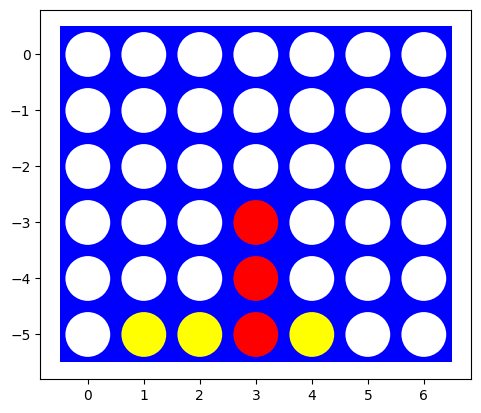

In [76]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()

board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)

Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

In [77]:
import numpy as np
import random

def empty_board(shape=(6,7)):
  #Create empty board
  return np.full(shape=shape, fill_value=0)

def actions(state):
  """Returns a list of columns that are not full"""
  return [col for col in range(state.shape[1]) if state[0][col] == 0]

def result(state, player, action):
  """Returns a new board after player drops a disc in the given column"""
  new_state = state.copy() # Copy the board so we don't modify the original state
  # Find the lowest empty row in the column
  for row in range(state.shape[0] - 1, -1, -1):
    if new_state[row][action] == 0:
      new_state[row][action] = player
      break
  return new_state

def check_winner(state):
  """Returns the winning player 1 or -1, or 0 if no winner"""
  rows, cols = state.shape
  for r in range(rows):
    for c in range(cols):
      if state[r][c] == 0:
        continue
      p = state[r][c]
      # Horizontal
      if c + 3 < cols and all(state[r][c+i] == p for i in range(4)):
        return p
      # Vertical
      if r + 3 < rows and all(state[r+i][c] == p for i in range(4)):
        return p
      # Diagonal down right
      if r + 3 < rows and c + 3 < cols and all(state[r+i][c+i] == p for i in range(4)):
        return p
      # Diagonal down left
      if r + 3 < rows and c - 3 >= 0 and all(state[r+i][c-i] == p for i in range(4)):
        return p
  return 0

def terminal(state):
  """Returns True if the game is over win or draw"""
  if check_winner(state) != 0:
    return True
  return len(actions(state)) == 0

def utility(state, player):
  """Returns +1 if player wins, -1 if player loses, 0 for draw"""
  winner = check_winner(state)
  if winner == player:
    return 1
  elif winner == -player:
    return -1
  else:
    return 0


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [78]:
def random_player(board, player=1):
    """Picks a random valid column"""
    return random.choice(actions(board))

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [79]:
def play_game(agent1, agent2, board=None):
  """Plays a full game between two agents returns 1 if player 1 wins, -1 if player 2 wins and 0 for draw"""
  if board is None:
    board = empty_board()
  player = 1  # Player 1 goes first
  while not terminal(board):
    if player == 1:
      action = agent1(board, player)
    else:
      action = agent2(board, player)
    board = result(board, player, action)
    player = -player  # switch turns
  return check_winner(board)

#Run 1000 games
wins_p1 = 0
wins_p2 = 0
draws = 0

for _ in range(1000):
  outcome = play_game(random_player, random_player)
  if outcome == 1:
    wins_p1 +=1
  elif outcome == -1:
    wins_p2 +=1
  else:
    draws +=1

print(f"Player 1 wins:  {wins_p1}")
print(f"Player 2 wins: {wins_p2}")
print(f"Draws: {draws}")


Player 1 wins:  540
Player 2 wins: 457
Draws: 3


## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points]

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [80]:
import time

def minimax_ab(board, player, is_maximizing, alpha, beta):
  """ Returns the minimax utility value for the current board state.
  Player is the player whose perspective we measure the utility from
  is_maximizing is True if the current player is the maximizing player
  """
  node_counter[0] += 1
  if terminal(board):
    return utility(board, player)
  # Determine whose turn it is
  current_player = player if is_maximizing else -player
  if is_maximizing:
    value = -np.inf
    for action in actions(board):
      child = result(board, current_player, action)
       # Recurse switching to minimizing player
      value = max(value, minimax_ab(child, player, False, alpha, beta))
      alpha = max(alpha, value)
      if alpha >= beta:
        break # Beta cutoff
    return value
  else:
    value = np.inf
    for action in actions(board):
      child = result(board, current_player, action)
      # Recurse switching to maximizing player
      value = min(value, minimax_ab(child, player, True, alpha, beta))
      beta = min(beta, value)
      if alpha >= beta:
        break # Alpha cutoff
    return value

def minimax_player(board, player=1):
  """Agent that uses minimax with alpha-beta pruning"""
  # Track the best move and its value
  best_value = -np.inf
  best_action = None
  alpha = -np.inf
  beta = np.inf
  #Evaluate each available move from player 1's perspective
  for action in actions(board):
    child = result(board, player, action)
    #Evaluate the resulting position from opponent's perspective
    value = minimax_ab(child, player, False, alpha, beta)
    if value > best_value:
      best_value = value
      best_action = action
    alpha = max(alpha, best_value)
  return best_action


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

In [81]:
#Board 1: Player 1 can win by playing column 3
board1 = np.array([
    [ 0,  0,  0,  0],
    [ 0,  0,  0,  0],
    [-1, -1, -1,  0],
    [ 1,  1,  1,  0]
])
print(minimax_player(board1, 1))

# Board 2: Player 1 must block Player 2 from four in a row at col 0
board2 = np.array([
    [ 0,  0,  0,  0],
    [-1,  0,  0,  0],
    [-1,  0,  0,  1],
    [-1,  0,  1,  1]
])
print(minimax_player(board2, 1))

#Board 3: Player 1 vertical win at col 2
board3 = np.array([
    [ 0,  0,  0,  0],
    [ 0,  0,  1,  0],
    [-1,  0,  1,  0],
    [-1, -1,  1,  0]
])
print(minimax_player(board3, 1))

#Board 4: Player 1 vertical win at col 3
board4 = np.array([
    [ 0,  0,  0,  0],
    [ 0,  0,  0, -1],
    [ 1,  0,  0, -1],
    [ 1,  1,  1, -1]
])
print(minimax_player(board4, -1))

# Board 5: Nearly full board, only col 3 open
board5 = np.array([
    [-1, -1, -1,  0,  1,  1,  1],
    [ 1,  1,  1,  0, -1, -1, -1],
    [-1, -1, -1,  0,  1,  1,  1],
    [ 1,  1,  1,  0, -1, -1, -1],
    [-1, -1, -1,  0,  1,  1,  1],
    [ 1,  1,  1,  0, -1, -1, -1]
])
print(minimax_player(board5, 1))

3
0
2
3
3


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

In [82]:
def time_minimax(rows, cols):
  """Measures the time of the first move on an empty board"""
  board = np.full((rows, cols), 0)
  start = time.time()
  move = minimax_player(board, 1)
  elapsed = time.time() - start
  return elapsed

#Testing
time_minimax(4, 4)
#time_minimax(4, 5)
#time_minimax(5, 5)
#time_minimax(5, 6)

4.126862525939941

The game tree grows exponetially with board size. On a 4x4 board the branching factor is 4 and games are at most 16 moves. On a standard 6x7 board, the branching factor starts at 7 and games can last up to 42 moves, creating a tree of 10^21 nodes. Even with alpha-beta pruning, this would take hours or days.

### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [83]:
def smart_order(board, current_player):
  """
  Chooses moves in priority order: moves that win immediately, moves that block the opponent from winning, remaining moves sorted by proximity to the center column
  """
  available = actions(board)
  #Separate moves into three categories by priority
  wins = []
  blocks = []
  rest = []
  opponent = -current_player
  center = board.shape[1]/2.0
  for c in available:
    child = result(board, current_player, c) # Check if playing this move wins immediately
    if check_winner(child) == current_player:
      wins.append(c)
    else:
      child_opp = result(board, opponent, c) # Check if this move would block an opponent's winning move
      if check_winner(child_opp) == opponent:
        blocks.append(c)
      else:
        rest.append(c)
  rest.sort(key=lambda col: abs(col - center)) # Sort remaining moves by the center column
  return wins + blocks + rest


def minimax_ab_ordered(board, player, is_maximizing, alpha, beta):
  node_counter[0] += 1 # Track total nodes visited
  if terminal(board):
    return utility(board, player)
  current_player = player if is_maximizing else -player
  ordered = smart_order(board, current_player)

  if is_maximizing:
    value = -np.inf
    for action in ordered:
      child = result(board, current_player, action)
      value = max(value, minimax_ab_ordered(child, player, False, alpha, beta))
      alpha = max(alpha, value)
      if alpha >= beta:
        break #Beta cutoff
    return value
  else:
    value = np.inf
    for action in ordered:
      child = result(board, current_player, action)
      value = min(value, minimax_ab_ordered(child, player, True, alpha, beta))
      beta = min(beta, value)
      if alpha >= beta:
        break #Alpha cutoff
    return value

def minimax_player_ordered(board, player=1):
  # Track the best move and its value
  best_value = -np.inf
  best_action = None
  alpha = -np.inf
  beta = np.inf
  for action in smart_order(board, player):
    child = result(board, player, action)
    value = minimax_ab_ordered(child, player, False, alpha, beta)
    if value > best_value:
      best_value = value
      best_action = action
    alpha = max(alpha, best_value)
  return best_action

def build_board(rows, cols, moves):
  board = np.full((rows, cols), 0)
  player = 1
  for move in moves:
    board = result(board, player, move)
    player = -player
  return board

# Various test boards
boards = [
  ("4x4 empty",    np.full((4,4), 0), 1),
  ("4x4 2 pcs",    build_board(4, 4, [1, 2]), 1),
  ("4x4 6 pcs",    build_board(4, 4, [0, 0, 1, 1, 2, 2]), 1),
]

# Clean boards
boards_clean = []
for item in boards:
  if len(item) == 3:
    boards_clean.append(item)
  else:
    boards_clean.append((item[0], item[1], 1))

print(f"{'Board':<15} {'Ordering':<12} {'Time':<12} {'Nodes':<12}")
node_counter = [0]
# Compare default and smart ordering
for label, board, player in boards_clean:
  for name, agent_fn in [("Default", minimax_player), ("Smart", minimax_player_ordered)]:
    #Reset node count and time the move
    node_counter[0] = 0
    start = time.time()
    move = agent_fn(board.copy(), player)
    elapsed = time.time() - start
    print(f"{label:<15} {name:<12} {elapsed:<12.3f} {node_counter[0]:<12}")
  print()

Board           Ordering     Time         Nodes       
4x4 empty       Default      2.092        62888       
4x4 empty       Smart        5.044        67863       

4x4 2 pcs       Default      0.372        15592       
4x4 2 pcs       Smart        0.331        5183        

4x4 6 pcs       Default      0.067        2669        
4x4 6 pcs       Smart        0.013        185         



### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

We can implement a depth-limited search with a heuristic evaluation function. This will stop at a fixed depth and check the board position using a heuristic such as center control instead of searching terminal states.

### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

In [84]:
def play_game(agent1, agent2):
  board = np.full((4, 4), 0)
  player = 1
  while not terminal(board):
    if player == 1:
      action = agent1(board, player)
    else:
      action = agent2(board, player)
    board = result(board, player, action)
    player = -player
  return check_winner(board)

# Minimax as Player 1 vs Random as Player 2
wins_mini = 0; wins_rand = 0; draws = 0
for i in range(100):
  outcome = play_game(minimax_player, random_player)
  if outcome == 1: wins_mini += 1
  elif outcome == -1: wins_rand += 1
  else: draws += 1
print("Minimax as Player 1 vs Random as Player 2 (100 games):")
print(f"  Minimax wins: {wins_mini}, Random wins: {wins_rand}, Draws: {draws}")

Minimax as P1 vs Random as P2 (100 games):
  Minimax wins: 69, Random wins: 0, Draws: 31


## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [85]:
def heuristic(board, player):
  """ Checks the board from player's perspective by scoring all windows of 4"""
  rows, cols = board.shape
  score = 0
  opponent = -player
  #Center column control
  center_col = cols//2
  center_count = np.sum(board[:, center_col] == player)
  score += center_count * 3

  #check every possible window of 4
  for r in range(rows):
    for c in range(cols):
      if c + 3 < cols:
        window = [board[r][c+i] for i in range(4)]
        score += score_window(window, player, opponent)
      #vertical
      if r + 3 < rows:
        window = [board[r+i][c] for i in range(4)]
        score += score_window(window, player, opponent)
      #Diagonal down right
      if r + 3 < rows and c + 3 < cols:
        window = [board[r+i][c+i] for i in range(4)]
        score += score_window(window, player, opponent)
      #Diagonal down left
      if r + 3 < rows and c - 3 >= 0:
        window = [board[r+i][c-i] for i in range(4)]
        score += score_window(window, player, opponent)
  return score

def score_window(window, player, opponent):
  #Count pieces of each type
  play = window.count(player)
  opp = window.count(opponent)
  empty = window.count(0)
  #Score based on how close to 4-in-a-row
  if play == 4: return 100
  if play == 3 and empty == 1: return 5
  if play == 2 and empty == 2: return 2
  if opp == 3 and empty == 1: return -4
  return 0

def minimax_ab_heuristic(board, player, is_maximizing, alpha, beta, depth):
  """Alpha Beta Minimax with heuristic depth limited evaluation function"""
  if terminal(board):
    u = utility(board, player)
    return u * 10000 #Scale above heuristic range
  if depth == 0: # Depth limit reached
    return heuristic(board, player)
  current_player = player if is_maximizing else -player
  ordered = smart_order(board, current_player) # Order moves to improve alpha-beta pruning
  if is_maximizing:
    value = -np.inf
    for action in ordered:
      child = result(board, current_player, action)
      value = max(value, minimax_ab_heuristic(child, player, False, alpha, beta, depth-1))
      alpha = max(alpha, value)
      if alpha >= beta:
        break #Beta cutoff
    return value
  else:
    value = np.inf
    for action in ordered:
      child = result(board, current_player, action)
      value = min(value, minimax_ab_heuristic(child, player, True, alpha, beta, depth-1))
      beta = min(beta, value)
      if alpha >= beta:
        break #Alpha cutoff
    return value

def minimax_heuristic_player(board, player=1, depth =6):
  """Depth limited minimax agent with heuristic evaluation function"""
  best_value = -np.inf
  best_action = None
  alpha = -np.inf
  beta = np.inf
  for action in smart_order(board, player): # Try moves in smart order
    child = result(board, player, action)
    value = minimax_ab_heuristic(child, player, False, alpha, beta, depth-1)
    if value > best_value:
      best_value = value
      best_action = action
    alpha = max(alpha, best_value)
  return best_action

### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [86]:
def minimax_ab_heuristic(board, player, is_maximizing, alpha, beta, depth):
  """Minimax with alpha-beta pruning, cuts off at given depth and uses heuristic."""
  if terminal(board):
    return utility(board, player) * 10000  #scale terminals above heuristic range
  if depth == 0:  #Stop if we've hit the depth limit
    return heuristic(board, player)

  current_player = player if is_maximizing else -player
  #Order moves to improve alpha-beta pruning
  ordered = smart_order(board, current_player)
  if is_maximizing:
    value = -np.inf
    for action in ordered:
      child = result(board, current_player, action)
      # Recurse with reduced depth, minimizing player
      value = max(value, minimax_ab_heuristic(child, player, False, alpha, beta, depth-1))
      alpha = max(alpha, value)
      if alpha >= beta:
        break #Beta cutoff
    return value
  else:
    value = np.inf
    for action in ordered:
      child = result(board, current_player, action)
      # Recurse with reduced depth, maximizing player
      value = min(value, minimax_ab_heuristic(child, player, True, alpha, beta, depth-1))
      beta = min(beta, value)
      if alpha >= beta:
        break #Alpha cutoff
    return value

def minimax_heuristic_player(board, player=1, depth =4):
  """Depth limited minimax agent"""
  best_value = -np.inf
  best_action = None
  alpha = -np.inf
  beta = np.inf
  # Try moves in smart order
  for action in smart_order(board, player):
    child = result(board, player, action)
    #Evaluate the resulting position
    value = minimax_ab_heuristic(child, player, False, alpha, beta, depth-1)
    if value > best_value:
      best_value = value
      best_action = action
    alpha = max(alpha, best_value)
  return best_action



Experiment with the same manually created boards as above to check if the agent spots wining opportunities.

In [87]:
print("Board 1 - P1 horizontal win:", minimax_heuristic_player(board1, 1, depth=4))
# Expected: 3

print("Board 2 - P1 blocks at col 0:", minimax_heuristic_player(board2, 1, depth=4))
# Expected: 0

print("Board 3 - P1 vertical win:", minimax_heuristic_player(board3, 1, depth=4))
# Expected: 2

print("Board 4 - P-1 vertical win:", minimax_heuristic_player(board4, -1, depth=4))
# Expected: 3

print("Board 5 - Only col 3 open:", minimax_heuristic_player(board5, 1, depth=4))
# Expected: 3

Board 1 - P1 horizontal win: 3
Board 2 - P1 blocks at col 0: 0
Board 3 - P1 vertical win: 2
Board 4 - P-1 vertical win: 3
Board 5 - Only col 3 open: 3


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [88]:
print(f"{'Board':<10} {'Time':<12} {'Move':<6}")

for cols in [4, 5, 6, 7]:
  board = np.full((6, cols), 0)
  t = time.time()
  move = minimax_heuristic_player(board, 1, depth=4)
  elapsed = time.time() - t
  print(f"6x{cols:<8} {elapsed:<12.5} {move:<6}")

Board      Time         Move  
6x4        0.0069656    2     
6x5        0.010055     2     
6x6        0.032887     3     
6x7        0.03091      3     


### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [89]:
def make_agent(depth): #Wraps minimax_heuristic_player
  return lambda board, player=1: minimax_heuristic_player(board, player, depth = depth)

deep_agent = make_agent(5)
shallow_agent = make_agent(2)

def play_fullgame(agent1, agent2): #Plays one full 6x7 game between two agents
  board = np.full((6, 7), 0)
  player = 1
  moves = 0
  while not terminal(board):
    if player == 1:
      action = agent1(board, player)
    else:
      action = agent2(board, player)
    board = result(board, player, action)
    player = -player
    moves += 1
  return check_winner(board), moves, board

print("Deep (depth=5) as Player 1 vs Shallow (depth=2) as Player 2:")
winner, moves, final = play_fullgame(deep_agent, shallow_agent)
print(f"Winner:{winner}, Moves played:{moves}")
print(final)



Deep (depth=5) as P1 vs Shallow (depth=2) as P2:
Winner:1, Moves played:9
[[ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0 -1  0  0  0]
 [ 0  0  0  1  0  0  0]
 [ 0  0  0 -1 -1  0  0]
 [ 0 -1  1  1  1  1  0]]


In [93]:
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")


KeyboardInterrupt: 

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above.

In [90]:
# Your code/ answer goes here.

### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

In [91]:
# Your code/ answer goes here.

## Competition task [extra course bonus will be awarded separately]

After you have implemented you agents, find another student and let your best agent play against the other student's best player. Check the Canvas Module called Competition, there you will find a page that explains the rules, how to compete in the tournament, and what the bonus points are. You can start the tournament once you have a working agent. the tournament will continue after the assignment submission deadline. Tournament deadlines can be found on Canvas.